<a href="https://colab.research.google.com/drive/1uBTife193s0VDvmCZH3UQG1Q-UMNEcNx" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transparent GPU-Hour Allocation

This notebook runs Team A's exact six-team comparison: random-order FCFS versus a carbon-aware VCG priority mechanism.

For each team, estimated emissions are $e_i = 0.24d_i$ and the selection score is $v_i - 0.5e_i$. The mechanism chooses the feasible group with the highest total score, subject to 100 GPU-hours.

**Research artifacts:** [GitHub repository](https://github.com/GihoonE/COMPSCI206-PS2/tree/ps2-review/colab) · [Hugging Face Space](https://huggingface.co/spaces/dku-comsci-econ206-2026/PS2_Team_A) (interactive version of the same rule)

**How to run:** in Colab choose *Runtime → Run all*. Everything the notebook needs is inside it. The last cell prints a fresh-run verification record, and every check must say PASS.

## Game design and solution benchmark

**Game class.** This is a static, simultaneous-move game with incomplete information. Each team privately knows its project value $v_i$ and simultaneously submits a report $r_i$. GPU demand $d_i$ and estimated emissions $e_i$ are observable.

**Auction format.** Our proposed rule is a sealed-bid, carbon-aware multi-team VCG direct mechanism: a generalization of second-price/Vickrey logic from one winner to a feasible group of teams. FCFS is a non-strategic baseline, not the auction game.

**Solution concept.** The benchmark is dominant-strategy incentive compatibility (DSIC): reporting $r_i=v_i$ is optimal for each team regardless of the other teams' reports, provided priority credits have a meaningful opportunity cost. DSIC is stronger than Bayesian Nash equilibrium (BNE), so truthful reporting is also a BNE. The condition is stated and proved below, then checked numerically.

## Game setup: a static game with incomplete information

- **Static:** every team submits one report at the same time and nobody sees the others' reports first. It is not an ascending (English) auction.
- **Incomplete information:** each team knows its own project value but not the other teams' values.

**Variables**

- $i \in \{A, B, C, D, E, F\}$: a project team (player)
- $v_i$: true project value, **private** (baseline: 3, 6, or 9)
- $r_i$: reported value, the team's action (a strategy maps $v_i \mapsto r_i$)
- $d_i$: GPU-hours requested, **public**
- $e_i = 0.24\,d_i$: estimated emissions in kg CO₂e, **public**
- $\lambda = 0.5$: carbon penalty per kg CO₂e
- $s_i = r_i - \lambda e_i = r_i - 0.12\,d_i$: selection score
- $K = 100$: shared GPU-hours
- $S$: a group of teams, feasible if $\sum_{i \in S} d_i \le K$
- $S^*$: the feasible group with the largest $\sum_{i \in S} s_i$ (all $2^6 = 64$ groups are checked)
- $W^*_{-i}$: the best total score the other teams could reach if $i$ were absent
- $p_i = W^*_{-i} - \sum_{j \in S^* \setminus \{i\}} s_j$: VCG payment in score units (×10 = priority credits)
- $u_i = v_i - \lambda e_i - p_i$ if $i \in S^*$, otherwise $u_i = 0$: payoff

**Timing**

1. Each team learns its own $v_i$.
2. All teams submit $r_i$ at the same time.
3. The rule selects $S^*$, allocates the full $d_i$ to each $i \in S^*$, and charges $p_i$.

Truthful reporting is optimal whatever the others report (DSIC), so teams need no beliefs about the other teams' values.

## Model code

The whole model is below, so this notebook runs on its own in Colab: no repository clone and no installs. The same code lives in `src/gpu_allocation.py`, and a repository test checks that the two are identical.

### Model code 1 · Primitives
Constants, one team (demand, true value, report), and an allocation outcome.

In [1]:
"""Exact carbon-aware VCG allocation of 100 shared GPU-hours.

Team A's model compares random-order FCFS with a static, incomplete-information
direct mechanism. Each real project team has a private project value report and
observable GPU demand/emissions:

    e_i = 0.24 * d_i
    reported_score_i = report_i - 0.5 * e_i = report_i - 0.12 * d_i

The mechanism selects the feasible group with the greatest total reported
score. With six teams, every one of the 2**6 = 64 possible groups is checked.
Selected teams pay VCG externality prices in non-transferable priority credits.

A team's utility counts its own announced carbon penalty:

    u_i = v_i - 0.5 * e_i - p_i   if selected, else 0

Under this utility, truthful reporting (r_i = v_i) is a dominant strategy (DSIC);
`misreport_sweep` checks this numerically.
"""

from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations, permutations
from statistics import mean
from typing import Iterable, Sequence

CAPACITY_GPU_HOURS = 100.0
EMISSIONS_KG_CO2E_PER_GPU_HOUR = 0.24
CARBON_PENALTY_PER_KG_CO2E = 0.5
PRIORITY_CREDITS_PER_SCORE_UNIT = 10.0


@dataclass(frozen=True)
class Team:
    """One real project team's request and private project-value report."""

    name: str
    demand_gpu_hours: float
    true_value: float
    reported_value: float

    @property
    def emissions_kg_co2e(self) -> float:
        return EMISSIONS_KG_CO2E_PER_GPU_HOUR * self.demand_gpu_hours

    @property
    def reported_score(self) -> float:
        return self.reported_value - CARBON_PENALTY_PER_KG_CO2E * self.emissions_kg_co2e

    @property
    def true_score(self) -> float:
        return self.true_value - CARBON_PENALTY_PER_KG_CO2E * self.emissions_kg_co2e


@dataclass(frozen=True)
class AllocationOutcome:
    mechanism: str
    selected_indices: tuple[int, ...]
    capacity_gpu_hours: float
    payments_score_units: dict[int, float]
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E

### Model code 2 · Exact search over every feasible group
All $2^6=64$ groups are enumerated; groups over 100 GPU-hours are dropped; the highest total score wins. Ties: more teams, then earlier team order.

In [2]:
def all_subsets(n_teams: int) -> Iterable[tuple[int, ...]]:
    for group_size in range(n_teams + 1):
        yield from combinations(range(n_teams), group_size)


def total_demand(teams: Sequence[Team], selected: Sequence[int]) -> float:
    return sum(teams[index].demand_gpu_hours for index in selected)


def reported_score(team: Team, carbon_penalty_per_kg_co2e: float) -> float:
    """Reported project value minus the announced carbon penalty."""

    return team.reported_value - carbon_penalty_per_kg_co2e * team.emissions_kg_co2e


def true_score(team: Team, carbon_penalty_per_kg_co2e: float) -> float:
    """True project value minus the announced carbon penalty."""

    return team.true_value - carbon_penalty_per_kg_co2e * team.emissions_kg_co2e


def total_reported_score(
    teams: Sequence[Team],
    selected: Sequence[int],
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E,
) -> float:
    return sum(
        reported_score(teams[index], carbon_penalty_per_kg_co2e)
        for index in selected
    )


def total_true_score(
    teams: Sequence[Team],
    selected: Sequence[int],
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E,
) -> float:
    return sum(
        true_score(teams[index], carbon_penalty_per_kg_co2e)
        for index in selected
    )


def best_feasible_subset(
    teams: Sequence[Team],
    capacity_gpu_hours: float = CAPACITY_GPU_HOURS,
    excluded_index: int | None = None,
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E,
) -> tuple[int, ...]:
    """Find the exact highest-reported-score group under the capacity limit.

    Ties are resolved by serving more teams, then by deterministic team order.
    This tie-breaker is public and used in every counterfactual calculation.
    """

    feasible = [
        subset
        for subset in all_subsets(len(teams))
        if excluded_index not in subset
        and total_demand(teams, subset) <= capacity_gpu_hours
    ]
    return max(
        feasible,
        key=lambda subset: (
            round(
                total_reported_score(
                    teams, subset, carbon_penalty_per_kg_co2e
                ),
                10,
            ),
            len(subset),
            tuple(-index for index in subset),
        ),
    )

### Model code 3 · VCG allocation and payments
For each winner $i$: remove $i$, re-solve to get $W^*_{-i}$, and charge $p_i = W^*_{-i} - \sum_{j\in S^*\setminus\{i\}} s_j$.

In [3]:
def vcg_allocation(
    teams: Sequence[Team],
    capacity_gpu_hours: float = CAPACITY_GPU_HOURS,
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E,
) -> AllocationOutcome:
    """Allocate by reported score and charge each winner's VCG externality."""

    selected = best_feasible_subset(
        teams, capacity_gpu_hours, carbon_penalty_per_kg_co2e=carbon_penalty_per_kg_co2e
    )
    payments: dict[int, float] = {}
    for winner in selected:
        # Best score available to everyone else if this winner had not participated.
        without_winner = best_feasible_subset(
            teams,
            capacity_gpu_hours,
            excluded_index=winner,
            carbon_penalty_per_kg_co2e=carbon_penalty_per_kg_co2e,
        )
        best_others_without_winner = total_reported_score(
            teams, without_winner, carbon_penalty_per_kg_co2e
        )

        # The score earned by everyone else in the actual winning group.
        actual_others_score = total_reported_score(
            teams,
            tuple(index for index in selected if index != winner),
            carbon_penalty_per_kg_co2e,
        )
        payments[winner] = round(
            max(0.0, best_others_without_winner - actual_others_score), 2
        )
    return AllocationOutcome(
        mechanism="Carbon-aware VCG allocation",
        selected_indices=selected,
        capacity_gpu_hours=capacity_gpu_hours,
        payments_score_units=payments,
        carbon_penalty_per_kg_co2e=carbon_penalty_per_kg_co2e,
    )

### Model code 4 · FCFS baseline
Serve full requests in arrival order while they fit.

In [4]:
def fcfs_allocation(
    teams: Sequence[Team],
    arrival_order: Sequence[int],
    capacity_gpu_hours: float = CAPACITY_GPU_HOURS,
) -> AllocationOutcome:
    """Serve full requests in a public arrival order; skip requests that do not fit."""

    remaining = capacity_gpu_hours
    selected: list[int] = []
    for index in arrival_order:
        if teams[index].demand_gpu_hours <= remaining:
            selected.append(index)
            remaining -= teams[index].demand_gpu_hours
    return AllocationOutcome(
        mechanism="Random-order FCFS",
        selected_indices=tuple(selected),
        capacity_gpu_hours=capacity_gpu_hours,
        payments_score_units={},
    )

### Model code 5 · Utility and the truthfulness sweep
$u_i = v_i - \lambda e_i - p_i$ if selected, else 0. `misreport_sweep` re-runs VCG with one team's report changed.

In [5]:
def team_utility(team: Team, outcome: AllocationOutcome, index: int) -> float:
    """True value minus own carbon penalty minus payment if selected, else 0."""

    if index not in outcome.selected_indices:
        return 0.0
    return (
        true_score(team, outcome.carbon_penalty_per_kg_co2e)
        - outcome.payments_score_units.get(index, 0.0)
    )


def misreport_sweep(
    teams: Sequence[Team],
    index: int,
    reports: Iterable[float],
    capacity_gpu_hours: float = CAPACITY_GPU_HOURS,
    carbon_penalty_per_kg_co2e: float = CARBON_PENALTY_PER_KG_CO2E,
) -> list[dict[str, object]]:
    """Re-run VCG with one team's report changed; everything else stays fixed.

    DSIC holds for this team and these rivals when no row's utility exceeds the
    utility of the truthful row (report == true_value).
    """

    rows: list[dict[str, object]] = []
    for report in reports:
        changed = list(teams)
        changed[index] = Team(
            teams[index].name,
            teams[index].demand_gpu_hours,
            teams[index].true_value,
            report,
        )
        outcome = vcg_allocation(
            changed, capacity_gpu_hours, carbon_penalty_per_kg_co2e
        )
        payment = outcome.payments_score_units.get(index, 0.0)
        rows.append(
            {
                "team": teams[index].name,
                "true_value": teams[index].true_value,
                "report": report,
                "truthful": report == teams[index].true_value,
                "selected": index in outcome.selected_indices,
                "payment_score_units": payment,
                "utility_score_units": round(
                    team_utility(changed[index], outcome, index), 2
                ),
            }
        )
    return rows

### Model code 6 · Random-order FCFS over all 720 orders

In [6]:
def fcfs_all_orders(
    teams: Sequence[Team], capacity_gpu_hours: float = CAPACITY_GPU_HOURS
) -> list[dict[str, object]]:
    """FCFS outcome for every possible arrival order (6! = 720), so no seed is needed."""

    rows = []
    for order in permutations(range(len(teams))):
        metrics = outcome_metrics(
            teams, fcfs_allocation(teams, order, capacity_gpu_hours)
        )
        metrics["arrival_order"] = " -> ".join(teams[i].name for i in order)
        rows.append(metrics)
    return rows


def summarize_fcfs_orders(
    teams: Sequence[Team], rows: Sequence[dict[str, object]]
) -> dict[str, object]:
    """Mean and range of each FCFS metric, and each team's chance of being served."""

    summary: dict[str, object] = {"orders": len(rows)}
    for key in (
        "teams_served",
        "gpu_hours_used",
        "total_true_project_value",
        "carbon_adjusted_true_score",
        "total_estimated_emissions_kg_co2e",
    ):
        values = [float(row[key]) for row in rows]
        summary[key] = {
            "mean": round(mean(values), 2),
            "min": min(values),
            "max": max(values),
        }
    summary["service_probability"] = {
        team.name: round(
            sum(team.name in str(row["selected_teams"]).split("; ") for row in rows)
            / len(rows),
            3,
        )
        for team in teams
    }
    return summary

### Model code 7 · Audit tables and the fixed six-team example

In [7]:
def team_rows(teams: Sequence[Team], outcome: AllocationOutcome) -> list[dict[str, object]]:
    """One transparent calculation row per team."""

    selected = set(outcome.selected_indices)
    rows: list[dict[str, object]] = []
    for index, team in enumerate(teams):
        served = index in selected
        payment_units = outcome.payments_score_units.get(index, 0.0)
        rows.append(
            {
                "team": team.name,
                "gpu_hours_requested": team.demand_gpu_hours,
                "true_value": team.true_value,
                "reported_value": team.reported_value,
                "estimated_emissions_kg_co2e": round(team.emissions_kg_co2e, 2),
                "reported_score": round(
                    reported_score(team, outcome.carbon_penalty_per_kg_co2e), 2
                ),
                "selected": served,
                "gpu_hours_allocated": team.demand_gpu_hours if served else 0.0,
                "priority_payment_score_units": payment_units if served else 0.0,
                "priority_payment_credits": round(
                    payment_units * PRIORITY_CREDITS_PER_SCORE_UNIT, 2
                )
                if served
                else 0.0,
                "utility_score_units": round(
                    team_utility(team, outcome, index), 2
                ),
            }
        )
    return rows


def outcome_metrics(teams: Sequence[Team], outcome: AllocationOutcome) -> dict[str, object]:
    selected = outcome.selected_indices
    allocated = total_demand(teams, selected)
    emissions = sum(teams[index].emissions_kg_co2e for index in selected)
    true_value = sum(teams[index].true_value for index in selected)
    true_score = total_true_score(
        teams, selected, outcome.carbon_penalty_per_kg_co2e
    )
    total_payment = sum(outcome.payments_score_units.values())
    return {
        "mechanism": outcome.mechanism,
        "selected_teams": "; ".join(teams[index].name for index in selected),
        "teams_served": len(selected),
        "gpu_hours_used": round(allocated, 2),
        "unused_gpu_hours": round(outcome.capacity_gpu_hours - allocated, 2),
        "total_true_project_value": round(true_value, 2),
        "carbon_adjusted_true_score": round(true_score, 2),
        "total_estimated_emissions_kg_co2e": round(emissions, 2),
        "total_priority_payment_score_units": round(total_payment, 2),
        "total_priority_payment_credits": round(
            total_payment * PRIORITY_CREDITS_PER_SCORE_UNIT, 2
        ),
        "carbon_penalty_per_kg_co2e": outcome.carbon_penalty_per_kg_co2e,
    }


def default_example() -> tuple[list[Team], tuple[int, ...]]:
    """Fixed six-team example using the project's Low/Medium/High value tiers."""

    teams = [
        Team("Team A", 25, true_value=9, reported_value=9),   # High
        Team("Team B", 20, true_value=6, reported_value=6),   # Medium
        Team("Team C", 15, true_value=3, reported_value=3),   # Low
        Team("Team D", 25, true_value=9, reported_value=9),   # High
        Team("Team E", 20, true_value=6, reported_value=6),   # Medium
        Team("Team F", 15, true_value=3, reported_value=3),   # Low
    ]
    # One illustrative draw of the random order; fcfs_all_orders covers all 720 orders.
    arrival_order = (0, 1, 4, 2, 3, 5)
    return teams, arrival_order

## Model inputs and exact algorithm

The code uses no random draws. The six team inputs are fixed. Random-order FCFS is computed exactly over all $6! = 720$ arrival orders, with one illustrative order shown first. Another reader should therefore reproduce the same output.

**Parameter table**

| Symbol | Meaning | Value |
|---|---|---|
| $K$ | shared GPU-hours | 100 |
| $n$ | project teams | 6 |
| $d_i$ | GPU-hours requested (observable) | A, D: 25 · B, E: 20 · C, F: 15 |
| $v_i$ | true project value (private) | A, D: 9 · B, E: 6 · C, F: 3 (High / Medium / Low) |
| $r_i$ | reported value | $r_i = v_i$ in the baseline |
| $e_i$ | estimated emissions, kg CO₂e | $0.24\,d_i$ |
| $\lambda$ | carbon penalty per kg CO₂e | 0.5 (sensitivity: 0, 1) |
| — | priority credits per score unit | 10 |

**Language-independent pseudocode**

1. Read each team's demand $d_i$, reported value $r_i$, and observable emissions $e_i=0.24d_i$.
2. FCFS baseline: for an arrival order, serve each full request if it fits in the remaining capacity; skip it otherwise. Repeat for all 720 orders.
3. VCG: enumerate all 64 groups of the six teams and drop groups whose total demand exceeds $K$.
4. Select the feasible group $S^*$ with the largest total score $\sum_{i\in S}(r_i-\lambda e_i)$. Ties go to more teams, then earlier team order.
5. For each $i \in S^*$: remove $i$, solve again to get $W^*_{-i}$, and charge $p_i = W^*_{-i} - \sum_{j\in S^*\setminus i}(r_j-\lambda e_j)$ in priority credits.
6. Report allocation, payments, utility $u_i = v_i-\lambda e_i-p_i$ (0 if not selected), project value, carbon-adjusted score, GPU use, unused capacity, and emissions.
7. DSIC check: for each team, re-run steps 3–6 with its report changed and rivals fixed, and confirm that no report beats $r_i=v_i$.

In [8]:
parameters = {
    'teams': 6,
    'capacity_gpu_hours': CAPACITY_GPU_HOURS,
    'emissions_kg_co2e_per_gpu_hour': EMISSIONS_KG_CO2E_PER_GPU_HOUR,
    'baseline_carbon_penalty_lambda': CARBON_PENALTY_PER_KG_CO2E,
    'priority_credits_per_score_unit': PRIORITY_CREDITS_PER_SCORE_UNIT,
    'FCFS_illustrative_arrival_order': 'A -> B -> E -> C -> D -> F',
    'FCFS_orders_checked': 720,
}
for name, value in parameters.items():
    print(f'{name}: {value}')

teams: 6
capacity_gpu_hours: 100.0
emissions_kg_co2e_per_gpu_hour: 0.24
baseline_carbon_penalty_lambda: 0.5
priority_credits_per_score_unit: 10.0
FCFS_illustrative_arrival_order: A -> B -> E -> C -> D -> F
FCFS_orders_checked: 720


In [9]:
# The six teams use the project's Low / Medium / High values: 3, 6, and 9.
teams, arrival_order = default_example()
fcfs = fcfs_allocation(teams, arrival_order, CAPACITY_GPU_HOURS)
vcg = vcg_allocation(teams, CAPACITY_GPU_HOURS)

fcfs_summary = outcome_metrics(teams, fcfs)
vcg_summary = outcome_metrics(teams, vcg)

print('FCFS arrival order:', ' -> '.join(teams[i].name for i in arrival_order))
print('FCFS selected teams:', fcfs_summary['selected_teams'])
print('VCG selected teams:', vcg_summary['selected_teams'])


FCFS arrival order: Team A -> Team B -> Team E -> Team C -> Team D -> Team F
FCFS selected teams: Team A; Team B; Team E; Team C; Team F
VCG selected teams: Team A; Team B; Team D; Team E


In [10]:
# Compact actual-output table for the paper, poster, and Hugging Face audit.
metrics = [
    'teams_served', 'gpu_hours_used', 'unused_gpu_hours',
    'total_true_project_value', 'carbon_adjusted_true_score',
    'total_estimated_emissions_kg_co2e', 'total_priority_payment_credits',
]
print(f"{'metric':38} {'FCFS':>12} {'carbon-aware VCG':>20}")
print('-' * 74)
for metric in metrics:
    print(f"{metric:38} {str(fcfs_summary[metric]):>12} {str(vcg_summary[metric]):>20}")


metric                                         FCFS     carbon-aware VCG
--------------------------------------------------------------------------
teams_served                                      5                    4
gpu_hours_used                                   95                   90
unused_gpu_hours                                5.0                 10.0
total_true_project_value                         27                   30
carbon_adjusted_true_score                     15.6                 19.2
total_estimated_emissions_kg_co2e              22.8                 21.6
total_priority_payment_credits                  0.0                 96.0


In [11]:
# VCG payment and utility audit: utility = true value - own carbon penalty - payment (score units).
print(f"{'team':8} {'selected':9} {'payment credits':17} {'utility score units':21}")
print('-' * 64)
for row in team_rows(teams, vcg):
    print(f"{row['team']:8} {str(row['selected']):9} {row['priority_payment_credits']:17.1f} {row['utility_score_units']:21.1f}")

team     selected  payment credits   utility score units  
----------------------------------------------------------------
Team A   True                   24.0                   3.6
Team B   True                   24.0                   1.2
Team C   False                   0.0                   0.0
Team D   True                   24.0                   3.6
Team E   True                   24.0                   1.2
Team F   False                   0.0                   0.0


## Solution concept: truthful reporting is a dominant strategy

| Format | Game class + solution | Equilibrium condition used | Benchmark strategy |
|---|---|---|---|
| Carbon-aware multi-team VCG | Static + incomplete information; direct mechanism; **DSIC (therefore also BNE)** | $u_i(v_i, v_i, r_{-i}) \ge u_i(v_i, r_i, r_{-i}) \quad \forall r_i, r_{-i}$ | $r_i = v_i$ |

**Utility.** Team $i$ bears its own announced carbon penalty:
$u_i = \mathbf{1}[i \in S^*(r)]\,\big(v_i - \lambda e_i - p_i\big)$.

**Proof sketch (Groves argument).** Let $W^*_{-i}$ be the best total score of the other teams without $i$. It does not depend on $r_i$. Substitute the payment from step 5:

$$u_i = \Big[(v_i-\lambda e_i)\,\mathbf{1}[i\in S^*] + \sum_{j\in S^*\setminus i}(r_j-\lambda e_j)\Big] - W^*_{-i}.$$

If $i$ loses, the bracket is the score of a group that excludes $i$. That group is optimal, so the bracket equals $W^*_{-i}$ and $u_i = 0$. The bracket is the total score of $S^*$ with $i$'s *true* value. The mechanism maximizes the same total with $i$'s *reported* value. Reporting $r_i=v_i$ therefore makes the mechanism choose the group that maximizes $i$'s utility, for every $r_{-i}$. $\blacksquare$

**Why the carbon term must be in the utility.** If $u_i = v_i - p_i$, the bracket becomes $v_i + \sum_{j\in S^*\setminus i}(r_j-\lambda e_j)$. The report that aligns the mechanism with it is $r_i = v_i + \lambda e_i$, so DSIC fails. The cells below check truthful reporting numerically for every team.

**Special case.** With one item, no capacity choice, and $\lambda=0$, the rule reduces to the Vickrey auction: $p_i$ is the highest competing report and $\beta(v)=v$.

In [12]:
# DSIC check: re-run VCG with one team's report changed; rivals and demands stay fixed.
reports = [step / 2 for step in range(21)]   # 0, 0.5, ..., 10
print(f"{'team':8} {'true v':>7} {'truthful u':>11} {'best u, any report':>19} {'check':>6}")
print('-' * 56)
for index, team in enumerate(teams):
    rows = misreport_sweep(teams, index, reports)
    truthful = next(row for row in rows if row['truthful'])['utility_score_units']
    best = max(row['utility_score_units'] for row in rows)
    assert best <= truthful + 1e-9
    print(f"{team.name:8} {team.true_value:>7} {truthful:>11} {best:>19} {'PASS':>6}")

team      true v  truthful u  best u, any report  check
--------------------------------------------------------
Team A         9         3.6                 3.6   PASS
Team B         6         1.2                 1.2   PASS
Team C         3         0.0                 0.0   PASS
Team D         9         3.6                 3.6   PASS
Team E         6         1.2                 1.2   PASS
Team F         3         0.0                 0.0   PASS


In [13]:
# Team C in detail: truthful (3) loses the seat; reporting 4.2 or more wins it, but the seat costs more than it is worth.
print(f"{'report':>6} {'selected':>9} {'payment':>8} {'u = v - λe - p':>15}")
print('-' * 42)
for row in misreport_sweep(teams, 2, [2, 3, 4, 4.5, 5, 6, 8]):
    mark = '  <- truthful' if row['truthful'] else ''
    print(f"{row['report']:>6} {str(row['selected']):>9} {row['payment_score_units']:>8} "
          f"{row['utility_score_units']:>15}{mark}")

report  selected  payment  u = v - λe - p
------------------------------------------
     2     False      0.0             0.0
     3     False      0.0             0.0  <- truthful
     4     False      0.0             0.0
   4.5      True      2.4            -1.2
     5      True      2.4            -1.2
     6      True      2.4            -1.2
     8      True      2.4            -1.2


### Utility as a function of the report

Each panel fixes the other five teams and moves one team's report $r_i$ from 0 to 10.

- Solid line: utility $u_i = v_i - \lambda e_i - p_i$ if selected, otherwise 0.
- Dotted vertical line: the team's true value $v_i$.

**How to read it.** If truth-telling is dominant, no point on the solid line is higher than its value at the dotted line. Reporting less can only lose a profitable seat. Reporting more can only win a seat whose price exceeds its worth.

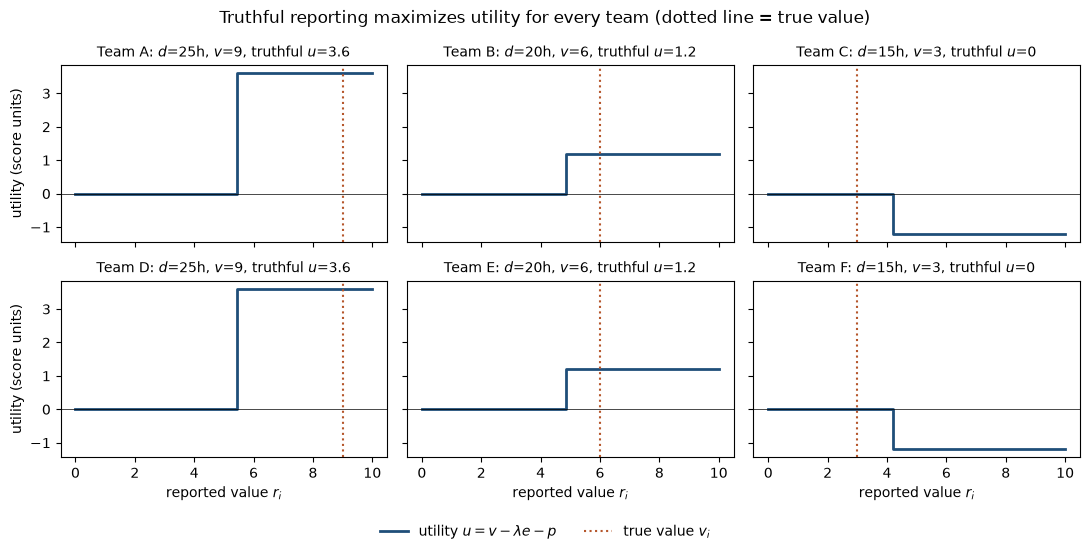

In [14]:
# Utility vs. report for every team (rivals fixed). Matplotlib ships with Colab.
import matplotlib.pyplot as plt

grid = [step / 20 for step in range(201)]   # reports 0, 0.05, ..., 10
fig, axes = plt.subplots(2, 3, figsize=(11, 5.5), sharex=True, sharey=True)
for index, (team, ax) in enumerate(zip(teams, axes.ravel())):
    rows = misreport_sweep(teams, index, grid)
    ax.step(grid, [r['utility_score_units'] for r in rows], where='post',
            color='#1f4e79', lw=2, label=r'utility $u = v - \lambda e - p$')
    ax.axvline(team.true_value, color='#b5562b', ls=':', lw=1.5, label='true value $v_i$')
    ax.axhline(0, color='black', lw=0.5)
    truthful_u = next(r for r in misreport_sweep(teams, index, [team.true_value]))['utility_score_units']
    ax.set_title(f'{team.name}: $d$={team.demand_gpu_hours:g}h, $v$={team.true_value:g}, '
                 f'truthful $u$={truthful_u:g}', fontsize=10)
for ax in axes[1]:
    ax.set_xlabel('reported value $r_i$')
for ax in axes[:, 0]:
    ax.set_ylabel('utility (score units)')
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='lower center', ncol=2, frameon=False)
fig.suptitle('Truthful reporting maximizes utility for every team (dotted line = true value)', fontsize=12)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## Random-order FCFS over every arrival order

Random-order FCFS depends on luck. Instead of sampling with a seed, the cell computes all $6! = 720$ orders exactly and compares their distribution with the single VCG outcome.

In [15]:
all_orders = fcfs_all_orders(teams, CAPACITY_GPU_HOURS)
order_summary = summarize_fcfs_orders(teams, all_orders)
print(f"{'metric':36} {'FCFS mean':>10} {'FCFS min–max':>14} {'VCG':>8}")
print('-' * 72)
for key in ['teams_served', 'gpu_hours_used', 'total_true_project_value',
            'carbon_adjusted_true_score', 'total_estimated_emissions_kg_co2e']:
    s = order_summary[key]
    print(f"{key:36} {s['mean']:>10} {str(s['min']) + '–' + str(s['max']):>14} {vcg_summary[key]:>8}")
print('\nChance of being served under FCFS:', order_summary['service_probability'])
print('VCG serves:', vcg_summary['selected_teams'])

metric                                FCFS mean   FCFS min–max      VCG
------------------------------------------------------------------------
teams_served                               4.93        4.0–5.0        4
gpu_hours_used                             97.0     90.0–100.0       90
total_true_project_value                   28.6      27.0–30.0       30
carbon_adjusted_true_score                16.96      15.6–19.2     19.2
total_estimated_emissions_kg_co2e         23.28      21.6–24.0     21.6

Chance of being served under FCFS: {'Team A': 0.767, 'Team B': 0.767, 'Team C': 0.933, 'Team D': 0.767, 'Team E': 0.767, 'Team F': 0.933}
VCG serves: Team A; Team B; Team D; Team E


## Carbon-penalty sensitivity check

The baseline uses $\lambda=0.5$. This check changes only the announced carbon-penalty weight, while holding demands, values, capacity, and the allocation algorithm fixed. It is a model robustness check, not new behavioral evidence.


In [16]:
for penalty in (0.0, 0.5, 1.0):
    sensitivity_outcome = vcg_allocation(
        teams, CAPACITY_GPU_HOURS, carbon_penalty_per_kg_co2e=penalty
    )
    sensitivity = outcome_metrics(teams, sensitivity_outcome)
    print(
        f"lambda={penalty:.1f} | selected: {sensitivity['selected_teams']} | "
        f"GPU-hours: {sensitivity['gpu_hours_used']} | "
        f"emissions: {sensitivity['total_estimated_emissions_kg_co2e']} | "
        f"score: {sensitivity['carbon_adjusted_true_score']}"
    )


lambda=0.0 | selected: Team A; Team B; Team C; Team D; Team F | GPU-hours: 100 | emissions: 24.0 | score: 30.0
lambda=0.5 | selected: Team A; Team B; Team D; Team E | GPU-hours: 90 | emissions: 21.6 | score: 19.2
lambda=1.0 | selected: Team A; Team B; Team D; Team E | GPU-hours: 90 | emissions: 21.6 | score: 8.4


In [17]:
# Fresh-run verification record.
import platform
from datetime import datetime, timezone

checks = {
    'FCFS illustrative order uses 95 GPU-hours': fcfs_summary['gpu_hours_used'] == 95.0,
    'VCG selects A, B, D, E using 90 GPU-hours': (vcg_summary['selected_teams'], vcg_summary['gpu_hours_used']) == ('Team A; Team B; Team D; Team E', 90.0),
    'VCG total true value 30, carbon-adjusted score 19.2': (vcg_summary['total_true_project_value'], vcg_summary['carbon_adjusted_true_score']) == (30.0, 19.2),
    'VCG payments total 96 credits': vcg_summary['total_priority_payment_credits'] == 96.0,
    'Utilities A-F = 3.6, 1.2, 0, 3.6, 1.2, 0': [r['utility_score_units'] for r in team_rows(teams, vcg)] == [3.6, 1.2, 0.0, 3.6, 1.2, 0.0],
    'Truthful reporting optimal for all six teams': all(
        max(r['utility_score_units'] for r in misreport_sweep(teams, i, reports))
        <= next(r for r in misreport_sweep(teams, i, reports) if r['truthful'])['utility_score_units'] + 1e-9
        for i in range(len(teams))),
    'FCFS covers 720 orders; none beats VCG score': order_summary['orders'] == 720
        and order_summary['carbon_adjusted_true_score']['max'] <= vcg_summary['carbon_adjusted_true_score'],
}
print('Run at (UTC):', datetime.now(timezone.utc).isoformat(timespec='seconds'))
print('Python:', platform.python_version(), '|', platform.platform())
for name, ok in checks.items():
    print(('PASS  ' if ok else 'FAIL  ') + name)
assert all(checks.values())

Run at (UTC): 2026-09-26T00:08:06+00:00
Python: 3.14.7 | macOS-26.6.2-arm64-arm-64bit-Mach-O
PASS  FCFS illustrative order uses 95 GPU-hours
PASS  VCG selects A, B, D, E using 90 GPU-hours
PASS  VCG total true value 30, carbon-adjusted score 19.2
PASS  VCG payments total 96 credits
PASS  Utilities A-F = 3.6, 1.2, 0, 3.6, 1.2, 0
PASS  Truthful reporting optimal for all six teams
PASS  FCFS covers 720 orders; none beats VCG score


`run_simulation.py` writes the same results to `outputs/`: `summary.csv`, `fcfs_team_results.csv`, `vcg_team_results.csv`, `fcfs_all_orders.csv`, and `truthfulness_check.csv`. Automated tests: `python -m unittest discover -s tests -v`.